In [1]:
N = 10000

Exponential distribution

$X = -\frac{\log(U)}{\lambda}$

$X \sim \exp(\lambda)$

In [ ]:
import numpy as np

lam = 1

u = np.random.rand(N)

x_exp = -np.log(u)/lam

array([0.69852838, 1.51187255, 1.36273293, ..., 0.5015683 , 0.16056709,
       0.34692034], shape=(10000,))

$f(x) = \lambda e^{-\lambda x} \rightarrow f(x) = e^{-e}$

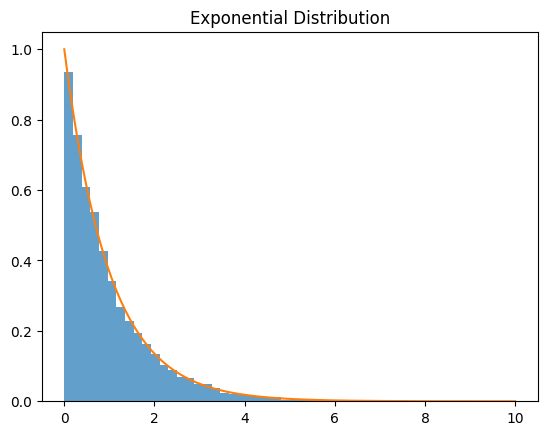

In [5]:
import matplotlib.pyplot as plt
from scipy.stats import expon

plt.hist(
    x_exp,
    bins=50,
    density=True,
    alpha=0.7
)

x = np.linspace(0,10,500)

plt.plot(
    x,
    expon.pdf(x,scale=1)
)

plt.title("Exponential Distribution")
plt.show()

$H_0 : X \sim \exp(1)$

In [7]:
from scipy.stats import kstest

ks_exp = kstest(
    x_exp,
    "expon"
)

ks_exp

KstestResult(statistic=np.float64(0.011734358078181795), pvalue=np.float64(0.1263304428180928), statistic_location=np.float64(0.8078077903896085), statistic_sign=np.int8(1))

pvalue > 0.05, generated sample agrees with theory.

Normal distribution

$Z_1=\sqrt{-2\log(U_1)}\cos(2\pi U_2)$

$Z_2=\sqrt{-2\log(U_1)}\sin(2\pi U_2)$

In [8]:
u1 = np.random.rand(N)
u2 = np.random.rand(N)

z1 = np.sqrt(
    -2*np.log(u1)
) * np.cos(
    2*np.pi*u2
)

z2 = np.sqrt(
    -2*np.log(u1)
) * np.sin(
    2*np.pi*u2
)

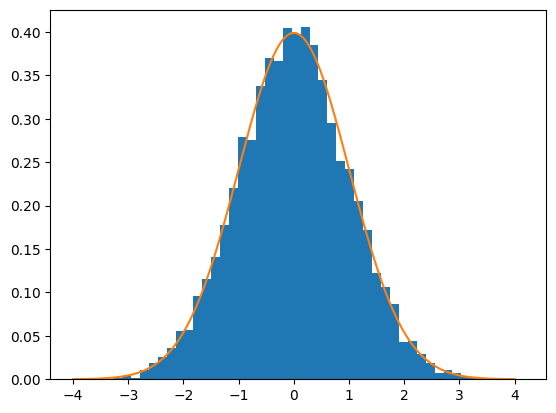

In [9]:
from scipy.stats import norm

plt.hist(
    z1,
    bins=50,
    density=True
)

x = np.linspace(-4,4,500)

plt.plot(
    x,
    norm.pdf(x)
)

plt.show()

In [10]:
ks_norm = kstest(
    z1,
    "norm"
)

print(ks_norm)

KstestResult(statistic=np.float64(0.007458405368468313), pvalue=np.float64(0.6313772948600185), statistic_location=np.float64(0.4005970597784919), statistic_sign=np.int8(1))


Pareto distribution with $\beta = 1$. $\quad k = 2.05, \: 2.5, \: 3, \: 4$

$X = \beta U^{-\frac{1}{k}}$

In [11]:
beta = 1

k_values = [2.05, 2.5, 3, 4]

In [12]:
def pareto_sample(k,beta,n):

    u = np.random.rand(n)

    return beta * u**(-1/k)

In [13]:
samples = {}

for k in k_values:
    samples[k] = pareto_sample(
        k,
        beta,
        N
    )

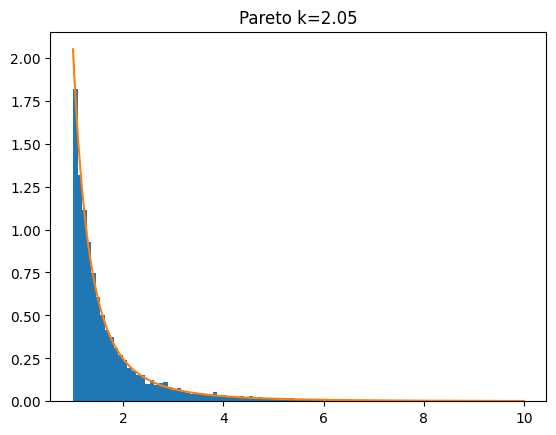

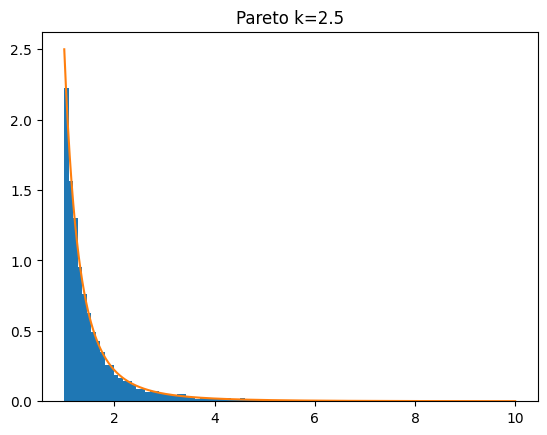

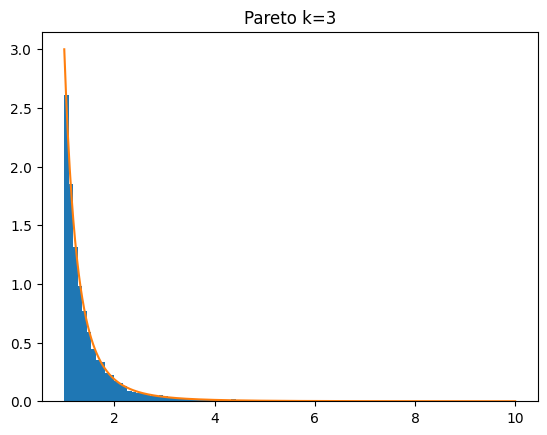

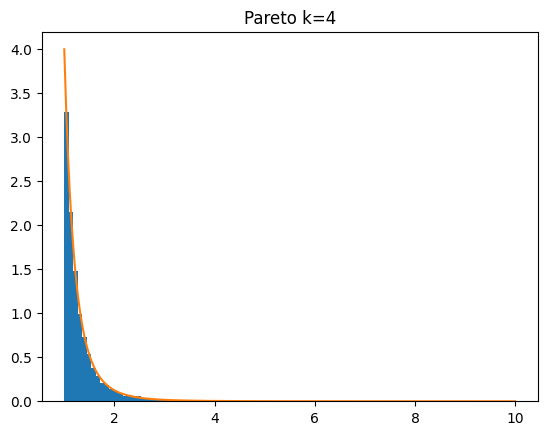

In [14]:
from scipy.stats import pareto

for k in k_values:

    data = samples[k]

    plt.figure()

    plt.hist(
        data,
        bins=100,
        density=True,
        range=(1,10)
    )

    x = np.linspace(1,10,500)

    plt.plot(
        x,
        pareto.pdf(x,k)
    )

    plt.title(
        f"Pareto k={k}"
    )

    plt.show()

In [15]:
for k in k_values:

    result = kstest(
        samples[k],
        "pareto",
        args=(k,)
    )

    print(k,result)

2.05 KstestResult(statistic=np.float64(0.011617863267581852), pvalue=np.float64(0.1333989520792329), statistic_location=np.float64(2.695431243649466), statistic_sign=np.int8(-1))
2.5 KstestResult(statistic=np.float64(0.008707369831682576), pvalue=np.float64(0.43194531301077077), statistic_location=np.float64(1.2888101120973463), statistic_sign=np.int8(1))
3 KstestResult(statistic=np.float64(0.010836935404406334), pvalue=np.float64(0.18943263719760983), statistic_location=np.float64(1.2024755289791391), statistic_sign=np.int8(1))
4 KstestResult(statistic=np.float64(0.008857223726061458), pvalue=np.float64(0.41038261796057796), statistic_location=np.float64(1.2977546557489892), statistic_sign=np.int8(1))


Part 2 - Mean and Variance of Pareto

$E[X] = \beta \frac{k}{k-1}$

$V[X] = \beta^2 \frac{k}{(k-1)^2(k-2)}$

Theoretical values, $\beta = 1$

|k  |  Mean| Variance |
|---|---|---|
| 2.05  | 1.952  | 18.59  |
|  2.5 | 1.667  |  2.222 |
|  3 | 1.5  |  0.75 |
|  4 |  1.333 |  0.222 |

Simulated values

In [16]:
for k in k_values:

    data = samples[k]

    mean_sim = np.mean(data)

    var_sim = np.var(
        data,
        ddof=1
    )

    print(
        k,
        mean_sim,
        var_sim
    )

2.05 1.9784779610991023 5.012450556762128
2.5 1.6742746853082382 3.740345264289598
3 1.4948757295174393 0.6194543262725924
4 1.3299955481360757 0.2054273995085154


Part 3 - Confidence Intervals

$n = 10, CI = 95\%$

We assume $X \sim N(0,1)$

$\bar{X} \pm t_{0.975, 9}\frac{S}{\sqrt{n}}$

In [17]:
n = 10
M = 100

In [18]:
from scipy.stats import t

mu_true = 0

covered = 0

intervals = []

for _ in range(100):

    sample = np.random.normal(
        0,
        1,
        n
    )

    xbar = np.mean(sample)

    s = np.std(
        sample,
        ddof=1
    )

    tcrit = t.ppf(
        0.975,
        n-1
    )

    lower = (
        xbar -
        tcrit*s/np.sqrt(n)
    )

    upper = (
        xbar +
        tcrit*s/np.sqrt(n)
    )

    intervals.append(
        (lower,upper)
    )

    if lower <= mu_true <= upper:
        covered += 1

In [19]:
print(
    covered/100
)

0.95


$\frac{(n-1)S^2}{\chi^2_{0.975}}\lt \sigma^2 \lt \frac{(n-1)S^2}{\chi^2_{0.025}}$

In [22]:
from scipy.stats import chi2

sigma2_true = 1

covered_var = 0

for _ in range(100):

    sample = np.random.normal(
        0,
        1,
        n
    )

    s2 = np.var(
        sample,
        ddof=1
    )

    lower = (
        (n-1)*s2
        /
        chi2.ppf(
            0.975,
            n-1
        )
    )

    upper = (
        (n-1)*s2
        /
        chi2.ppf(
            0.025,
            n-1
        )
    )

    if lower <= 1 <= upper:
        covered_var += 1

In [23]:
print(
    covered_var/100
)

0.94


Only 100 intervals = variance in coverage

Part 4

In [1]:
import numpy as np

def pareto_inverse(beta, k, n):

    u = np.random.rand(n)

    return beta * u**(-1/k)

In [2]:
def pareto_composition(mu, n):

    samples = []

    for _ in range(n):

        y = np.random.exponential(
            scale=1/mu
        )

        x = np.random.exponential(
            scale=1/y
        )

        samples.append(x)

    return np.array(samples)

In [9]:
N = 10000

inverse_sample = pareto_inverse(
    beta=1,
    k=1,
    n=N
)

composition_sample = pareto_composition(
    mu=1,
    n=N
)

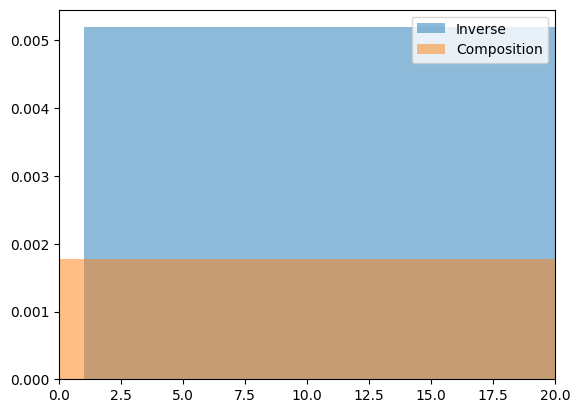

In [10]:
import matplotlib.pyplot as plt

plt.hist(
    inverse_sample,
    bins=100,
    density=True,
    alpha=0.5,
    label="Inverse"
)

plt.hist(
    composition_sample,
    bins=100,
    density=True,
    alpha=0.5,
    label="Composition"
)

plt.xlim(0,20)

plt.legend()

plt.show()

In [5]:
from scipy.stats import ks_2samp

result = ks_2samp(
    inverse_sample,
    composition_sample
)

print(result)

KstestResult(statistic=np.float64(0.4959), pvalue=np.float64(0.0), statistic_location=np.float64(1.0000126715832252), statistic_sign=np.int8(-1))


In [6]:
import time

start = time.time()
pareto_inverse(1, 1, 100000)
inverse_time = time.time() - start

start = time.time()
pareto_composition(1, 100000)
composition_time = time.time() - start

print("Inverse:", inverse_time)
print("Composition:", composition_time)

Inverse: 0.0010595321655273438
Composition: 0.14816856384277344
